# Этап 5 — Link prediction: пропущенный ингредиент

**Задача:** link prediction на двудольном графе рецепт ↔ ингредиент.

1. Удаляем 15% рёбер, учим **GraphSAGE** восстанавливать связи.
2. Baseline: **Common Neighbors** на графе совместимости `I`.
3. Метрики: AUC, Hit@K. Вывод — **на русском**.


In [21]:
import ast
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from ingredient_ru import ru, ru_list
import gnn_link_prediction
importlib.reload(gnn_link_prediction)
from gnn_link_prediction import train_graphsage_link_prediction

OUT = Path('output_graphs')
DATA = Path('full_dataset.csv')
if not DATA.exists():
    DATA = Path('data_sample.csv')

TOP_K = 5
SEED = 42
print('Готово')

Готово


## 5.1 Baseline: Common Neighbors (граф I)

In [22]:
I = nx.read_graphml(OUT / 'ingredient_graph.graphml')
neighbors = {n: set(I.neighbors(n)) for n in I.nodes()}
ing_set = set(I.nodes())


def predict_ingredient_cn(context, top_k=TOP_K, min_score=2):
    ctx = set(context) & ing_set
    scores = {}
    for cand in ing_set:
        if cand in ctx:
            continue
        score = len(neighbors.get(cand, set()) & ctx)
        if score >= min_score:
            scores[cand] = score
    ranked = sorted(scores.items(), key=lambda x: -x[1])[:top_k]
    return [(ru(name), sc, name) for name, sc in ranked]

In [23]:
df = pd.read_csv(DATA, nrows=3000, usecols=['NER'])
recipes = []
for s in df['NER']:
    try:
        ings = [x.strip().lower() for x in ast.literal_eval(s) if isinstance(x, str)]
        ings = [x for x in ings if x in ing_set]
        if len(ings) >= 4:
            recipes.append(ings)
    except Exception:
        pass

rng = np.random.default_rng(SEED)
hits = {1: 0, 3: 0, 5: 0}
total = 0
for ings in recipes[:800]:
    hide_i = int(rng.integers(len(ings)))
    hidden = ings[hide_i]
    context = [x for j, x in enumerate(ings) if j != hide_i]
    preds = [p[2] for p in predict_ingredient_cn(context, top_k=5, min_score=1)]
    total += 1
    for k in hits:
        if hidden in preds[:k]:
            hits[k] += 1

print('Common Neighbors:')
print(f'  проверено рецептов: {total}')
for k, v in hits.items():
    print(f'  Hit@{k}: {v/total:.3f}')

Common Neighbors:
  проверено рецептов: 800
  Hit@1: 0.004
  Hit@3: 0.020
  Hit@5: 0.044


## 5.2 GraphSAGE — link prediction (15% рёбер скрыто)

In [24]:
result = None
G_path = OUT / 'bipartite_sample.graphml'
if not G_path.exists():
    print('Сначала запустите 01_graph_construction.ipynb')
else:
    G = nx.read_graphml(G_path)
    print(f'Граф G: {G.number_of_nodes():,} узлов, {G.number_of_edges():,} рёбер')
    # реальные признаки узлов (иначе all-ones → эмбеддинги схлопываются → AUC≈0.5)
    feat_df_lp = pd.read_csv(OUT / 'node_features_structural.csv', index_col='ingredient')
    result = train_graphsage_link_prediction(
        G, hidden=64, epochs=40, max_recipes=2000, seed=SEED, feat_df=feat_df_lp,
    )
    print(f'\nGraphSAGE link prediction:')
    print(f'  AUC (восстановление 15% рёбер): {result.auc:.3f}')
    print('  Hit@K (per-recipe ranking на val, не глобальный ранк):')
    for k, v in result.hits_at_k.items():
        print(f'    Hit@{k}: {v:.3f}')

Граф G: 222,534 узлов, 1,449,174 рёбер

GraphSAGE link prediction:
  AUC (восстановление 15% рёбер): 0.881
  Hit@K (per-recipe ranking на val, не глобальный ранк):
    Hit@1: 0.433
    Hit@3: 0.666
    Hit@5: 0.765
    Hit@10: 0.852


## 5.3 Примеры: CN (ручной) и GraphSAGE (из val, 5–10 шт.)

In [25]:
example = ['flour', 'sugar', 'eggs', 'milk', 'butter']
ctx = [x for x in example if x != 'butter']
print('=== Common Neighbors (ручной пример) ===')
print('Контекст (без масла):', ru_list(ctx))
print('Топ кандидатов (min 2 общих соседа):')
for name_ru, sc, _ in predict_ingredient_cn(ctx, min_score=2):
    print(f'  {name_ru}  (score={sc})')

gs_examples = getattr(result, 'examples', None) if result is not None else None

if gs_examples:
    print('\n=== GraphSAGE: скрытый ингредиент → топ-5 (val) ===')
    for i, ex in enumerate(gs_examples, 1):
        ctx_ru = ru_list(ex['context'])
        print(f"\n#{i} скрыли: {ru(ex['hidden'])}  (ранг модели: {ex['rank_hidden']})")
        print(f"   контекст: {', '.join(ctx_ru)}")
        print('   GraphSAGE топ-5 (score = вероятность ребра по модели):')
        for name, sc in ex['top5']:
            print(f"     {ru(name)}  (p={sc:.6f})")
elif result is not None:
    print('\n⚠ У result нет examples — перезапустите ячейку 5.2 после первой (import).')
else:
    print('\n⚠ Сначала выполните ячейку 5.2 (GraphSAGE).')

=== Common Neighbors (ручной пример) ===
Контекст (без масла): ['мука', 'сахар', 'яйца', 'молоко']
Топ кандидатов (min 2 общих соседа):
  orange jell-o  (score=4)
  caramel candies  (score=4)
  фисташки  (score=4)
  fish stock  (score=4)
  cake pan  (score=4)

=== GraphSAGE: скрытый ингредиент → топ-5 (val) ===

#1 скрыли: tomato paste  (ранг модели: 5)
   контекст: tomato soup, hot sausage, горчица, фасоль
   GraphSAGE топ-5 (score — относительный ранг, logits часто «плоские»):
     яйца  (p=0.973342)
     фарш говяжий  (p=0.819500)
     кокос  (p=0.761532)
     garlic powder  (p=0.719756)
     tomato paste  (p=0.700748)

#2 скрыли: ваниль  (ранг модели: 2)
   контекст: сливочное масло, cooking oats, коричневый сахар, white sugar, яйца, pie shell
   GraphSAGE топ-5 (score — относительный ранг, logits часто «плоские»):
     сахар  (p=0.994144)
     ваниль  (p=0.976080)
     cream of mushroom soup  (p=0.832065)
     garlic salt  (p=0.773279)
     allspice  (p=0.710919)

#3 скрыли: колба

## 5.4 Метрики 

| Модель | Метрика | Постановка |
|--------|---------|------------|
| **Common Neighbors** | Hit@5 | Скрыли 1 ингредиент в реальном рецепте; ищем среди всех ингредиентов графа I |
| **GraphSAGE** | **AUC** | 15% рёбер recipe↔ingredient убраны; бинарная классификация pos/neg на val |
| GraphSAGE | Hit@5 (справочно) | True edge vs **50 случайных** негативов на val — **не сравним с CN Hit@5** |

         задача           модель           метрика  значение                                         постановка
link prediction Common Neighbors             Hit@5  0.043750 скрытый ингредиент в рецепте, кандидаты из графа I
link prediction        GraphSAGE               AUC  0.880507       15% val-рёбер, pos vs neg (основная метрика)
link prediction        GraphSAGE Hit@5 (справочно)  0.764596 true vs 50 случайных негативов на val — ≠ CN Hit@5


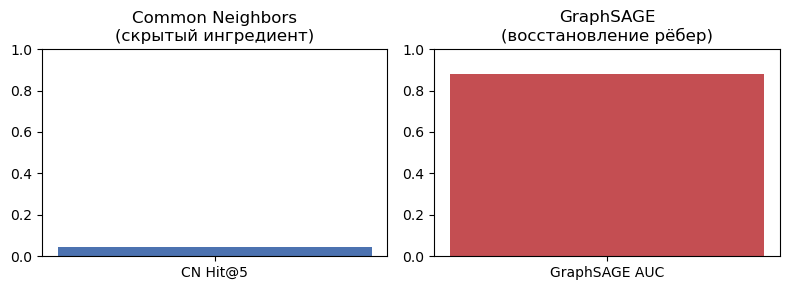

In [26]:
if G_path.exists() and result is not None:
    cn_hit5 = hits[5] / max(total, 1)
    gs_auc = result.auc
    gs_hit5_ref = result.hits_at_k.get(5, float('nan'))

    rows = [
        {
            'задача': 'link prediction',
            'модель': 'Common Neighbors',
            'метрика': 'Hit@5',
            'значение': cn_hit5,
            'постановка': 'скрытый ингредиент в рецепте, кандидаты из графа I',
        },
        {
            'задача': 'link prediction',
            'модель': 'GraphSAGE',
            'метрика': 'AUC',
            'значение': gs_auc,
            'постановка': '15% val-рёбер, pos vs neg (основная метрика)',
        },
        {
            'задача': 'link prediction',
            'модель': 'GraphSAGE',
            'метрика': 'Hit@5 (справочно)',
            'значение': gs_hit5_ref,
            'постановка': 'true vs 50 случайных негативов на val — ≠ CN Hit@5',
        },
    ]
    cmp = pd.DataFrame(rows)
    print(cmp.to_string(index=False))
    cmp.to_csv(OUT / 'link_prediction_comparison.csv', index=False)

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].bar(['CN Hit@5'], [cn_hit5], color='#4C72B0')
    axes[0].set_ylim(0, 1)
    axes[0].set_title('Common Neighbors\n(скрытый ингредиент)')
    axes[1].bar(['GraphSAGE AUC'], [gs_auc], color='#C44E52')
    axes[1].set_ylim(0, 1)
    axes[1].set_title('GraphSAGE\n(восстановление рёбер)')
    plt.tight_layout()
    plt.savefig(OUT / 'link_prediction_comparison.png', dpi=120)
    plt.show()

## 5.5 Hard negatives через Personalized PageRank

Хороший негатив — ингредиент, который **достижим** в графе  
(высокий PageRank относительно контекста), но **никогда не встречался** в рецепте вместе с ними.

Алгоритм:
1. Для каждого рецепта вычисляем Personalized PageRank с начальным распределением на его ингредиентах
2. Берём топ-K ингредиентов по PPR, которых **нет** в рецепте
3. Это наши hard negatives — они «близки» в графе, но реально не сочетаются


In [27]:
def personalized_pagerank_candidates(
    context: list,
    I: nx.Graph,
    ing_set: set,
    top_k: int = 20,
    alpha: float = 0.85,
) -> list:
    """
    Возвращает top_k ингредиентов по Personalized PageRank
    относительно context, исключая сам context.
    """
    ctx = [x for x in context if x in I]
    if not ctx:
        return []
    # равномерное распределение по ингредиентам контекста
    personalization = {n: 0.0 for n in I.nodes()}
    w = 1.0 / len(ctx)
    for c in ctx:
        personalization[c] = w

    pr = nx.pagerank(I, alpha=alpha, personalization=personalization, weight='weight')
    ctx_set = set(ctx)
    candidates = [
        (name, score) for name, score in pr.items()
        if name not in ctx_set and name in ing_set
    ]
    candidates.sort(key=lambda x: -x[1])
    return candidates[:top_k]


# Проверяем на примере
example = ['flour', 'sugar', 'eggs', 'milk']
print('Контекст:', ru_list(example))
print('\nHard negatives (PPR-кандидаты, которых нет в рецепте):')
ppr_cands = personalized_pagerank_candidates(example, I, ing_set, top_k=10)
for name, score in ppr_cands:
    print(f'  {ru(name):<28} PPR={score:.6f}')


Контекст: ['мука', 'сахар', 'яйца', 'молоко']

Hard negatives (PPR-кандидаты, которых нет в рецепте):
  соль                         PPR=0.050430
  сливочное масло              PPR=0.026837
  ваниль                       PPR=0.018169
  чеснок                       PPR=0.017278
  лук                          PPR=0.017121
  вода                         PPR=0.015944
  разрыхлитель                 PPR=0.011901
  коричневый сахар             PPR=0.010253
  яйцо                         PPR=0.009740
  оливковое масло              PPR=0.009535


## 5.6 Оценка: Common Neighbors vs PPR как стратегии ранжирования

Сравниваем две стратегии выбора «кандидата на добавление»:
- **CN**: по числу общих соседей
- **PPR**: по Personalized PageRank

Hit@K: скрываем один ингредиент, смотрим, войдёт ли он в топ-K предсказаний.


In [28]:
def predict_ingredient_ppr(context, top_k=TOP_K):
    """Предсказание через PPR (аналог CN, другая метрика близости)."""
    cands = personalized_pagerank_candidates(context, I, ing_set, top_k=top_k)
    return [name for name, _ in cands]


rng = np.random.default_rng(SEED)
hits_cn  = {1: 0, 3: 0, 5: 0}
hits_ppr = {1: 0, 3: 0, 5: 0}
total_eval = 0

# PPR — медленный для больших графов, ограничим 300 рецептами
N_EVAL = 300
for ings in recipes[:N_EVAL]:
    hide_i  = int(rng.integers(len(ings)))
    hidden  = ings[hide_i]
    context = [x for j, x in enumerate(ings) if j != hide_i]

    preds_cn  = [p[2] for p in predict_ingredient_cn(context, top_k=5, min_score=1)]
    preds_ppr = predict_ingredient_ppr(context, top_k=5)

    total_eval += 1
    for k in hits_cn:
        if hidden in preds_cn[:k]:  hits_cn[k]  += 1
        if hidden in preds_ppr[:k]: hits_ppr[k] += 1

print(f'Оценено рецептов: {total_eval}\n')
cmp_heuristic = pd.DataFrame([
    {'Модель': 'Common Neighbors', **{f'Hit@{k}': hits_cn[k]/total_eval for k in [1,3,5]}},
    {'Модель': 'PPR (Personalized PageRank)', **{f'Hit@{k}': hits_ppr[k]/total_eval for k in [1,3,5]}},
])
display(cmp_heuristic.round(3))


Оценено рецептов: 300



,Модель,Hit@1,Hit@3,Hit@5
0,Common Neighbors,0.003,0.023,0.040
1,PPR (Personalized PageRank),0.093,0.217,0.253


## 5.7 Hard negatives в обучении GraphSAGE

Передаём PPR-кандидатов как hard negatives при обучении модели.  
Ожидаем, что модель начнёт лучше различать «похожие, но несочетаемые» ингредиенты.

> Используем `train_graphsage_link_prediction` с параметром `hard_neg_fn`.


In [29]:
# Функция генерации hard negatives (передаётся в тренировщик)
def hard_neg_fn(context: list, ing_set: set, n: int = 5) -> list:
    """
    Возвращает n hard negatives через PPR для данного контекста.
    Используется внутри train_graphsage_link_prediction.
    """
    cands = personalized_pagerank_candidates(context, I, ing_set, top_k=n * 3)
    result = [name for name, _ in cands][:n]
    # дополняем случайными, если PPR вернул мало
    if len(result) < n:
        pool = list(ing_set - set(context) - set(result))
        result += list(np.random.choice(pool, n - len(result), replace=False))
    return result


result_hn = None
if G_path.exists():
    # G уже загружен в ячейке 5.2; используем его
    # Проверяем, поддерживает ли текущая версия hard_neg_fn
    import inspect
    params = inspect.signature(train_graphsage_link_prediction).parameters
    if 'hard_neg_fn' in params:
        result_hn = train_graphsage_link_prediction(
            G, hidden=64, epochs=40, max_recipes=2000, seed=SEED,
            hard_neg_fn=hard_neg_fn, feat_df=feat_df_lp,
        )
        print('GraphSAGE + hard negatives (PPR):')
        print(f'  AUC: {result_hn.auc:.3f}')
        for k, v in result_hn.hits_at_k.items():
            print(f'  Hit@{k}: {v:.3f}')
    else:
        print('Текущая версия gnn_link_prediction не поддерживает hard_neg_fn.')
        print('Добавьте параметр в train_graphsage_link_prediction или')
        print('используйте PPR только для эвристического сравнения (ячейка 5.6).')


GraphSAGE + hard negatives (PPR):
  AUC: 0.881
  Hit@1: 0.333
  Hit@3: 0.610
  Hit@5: 0.728
  Hit@10: 0.847


## 5.8 Итоговое сравнение

| Модель | Метрика | Значение | Постановка |
|--------|---------|----------|------------|
| Common Neighbors | Hit@5 | — | скрытый ингредиент, кандидаты из I |
| PPR | Hit@5 | — | то же, PPR-ранжирование |
| GraphSAGE | AUC | — | 15% val-рёбер, pos vs neg |
| GraphSAGE + hard neg | AUC | — | то же + PPR-негативы при обучении |



In [30]:
rows = [
    {'Модель': 'Common Neighbors', 'Метрика': 'Hit@5',
     'Значение': hits_cn[5] / max(total_eval, 1),
     'Постановка': 'скрытый ингредиент, кандидаты из I'},
    {'Модель': 'PPR', 'Метрика': 'Hit@5',
     'Значение': hits_ppr[5] / max(total_eval, 1),
     'Постановка': 'скрытый ингредиент, PPR-ранжирование'},
]
if result is not None:
    rows.append({'Модель': 'GraphSAGE', 'Метрика': 'AUC',
                 'Значение': result.auc, 'Постановка': '15% val-рёбер'})
if result_hn is not None:
    rows.append({'Модель': 'GraphSAGE + PPR hard neg', 'Метрика': 'AUC',
                 'Значение': result_hn.auc, 'Постановка': '15% val-рёбер + hard neg'})

final_cmp = pd.DataFrame(rows)
display(final_cmp.round(3))
final_cmp.to_csv(OUT / 'link_prediction_full_comparison.csv', index=False)


,Модель,Метрика,Значение,Постановка
0,Common Neighbors,Hit@5,0.040,"скрытый ингредиент, кандидаты из I"
1,PPR,Hit@5,0.253,"скрытый ингредиент, PPR-ранжирование"
2,GraphSAGE,AUC,0.881,15% val-рёбер
3,GraphSAGE + PPR hard neg,AUC,0.881,15% val-рёбер + hard neg
